# Lab 4 — Data Analysis and Visualization
**Dataset:** `food_delivery_orders.csv`

This notebook works through the 8 lab tasks using groupby/agg/pivot_table, correlation (Pearson vs Spearman), distribution-by-category plots, time-series resampling, faceting, and overplotting fixes as covered in Lab Manual 4.

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

df = pd.read_csv('food_delivery_orders.csv', parse_dates=['order_date'])
df.head()

,order_date,city,restaurant_category,cuisine,order_value,discount_percent,delivery_time_min,rating,profit_per_order
0,2023-01-01,Karachi,Fine Dining,Continental,2768.0,25.0,36.2,4.5,95.0
1,2023-01-01,Karachi,Fine Dining,Steakhouse,4979.0,44.8,23.3,4.8,-437.0
2,2023-01-01,Karachi,Cloud Kitchen,Indian,4008.0,11.9,39.6,4.2,618.0
3,2023-01-01,Islamabad,Fine Dining,Steakhouse,3260.0,8.3,35.8,4.5,423.0
4,2023-01-01,Karachi,Fast Food,Pizza,435.0,13.5,29.4,4.8,53.0


In [62]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   order_date           4200 non-null   datetime64[us]
 1   city                 4200 non-null   str           
 2   restaurant_category  4200 non-null   str           
 3   cuisine              4200 non-null   str           
 4   order_value          4200 non-null   float64       
 5   discount_percent     4200 non-null   float64       
 6   delivery_time_min    4200 non-null   float64       
 7   rating               4200 non-null   float64       
 8   profit_per_order     4200 non-null   float64       
dtypes: datetime64[us](1), float64(5), str(3)
memory usage: 295.4 KB


,order_date,order_value,discount_percent,delivery_time_min,rating,profit_per_order
count,4200,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000
mean,2023-09-30 13:56:13.714285,1148.395776,12.242762,34.541810,4.508952,57.370067
min,2023-01-01 00:00:00,150.000000,0.200000,10.000000,2.400000,-5994.457891
25%,2023-05-15 00:00:00,490.000000,5.800000,26.800000,4.300000,22.000000
50%,2023-09-28 00:00:00,740.500000,10.400000,32.500000,4.500000,80.000000
75%,2024-02-15 00:00:00,1259.250000,16.400000,38.400000,4.800000,159.000000
max,2024-06-30 00:00:00,15943.033840,45.000000,132.700000,5.000000,1423.000000
std,NaN,1513.776254,8.485195,14.594407,0.386613,524.064820


## Task 1 — Univariate, properly read
Management wants a single number for "typical delivery time." Before picking mean or median, look at the shape of the distribution.

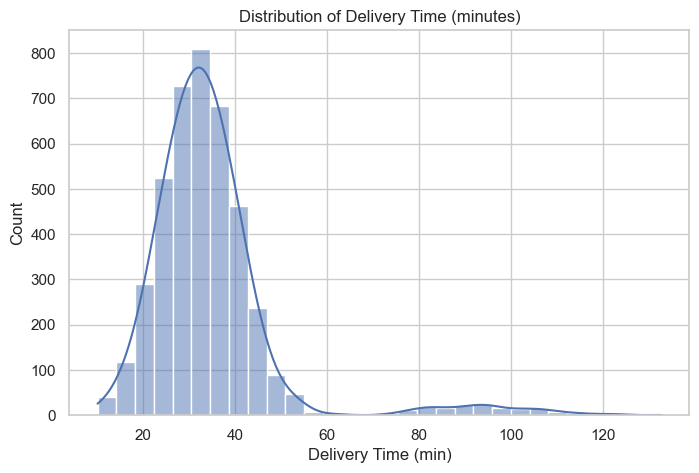

Skewness: 2.877
Mean: 34.54 min, Median: 32.50 min


In [63]:
plt.figure(figsize=(8,5))
sns.histplot(df['delivery_time_min'], kde=True, bins=30)
plt.title('Distribution of Delivery Time (minutes)')
plt.xlabel('Delivery Time (min)')
plt.show()

skew_val = df['delivery_time_min'].skew()
mean_val = df['delivery_time_min'].mean()
median_val = df['delivery_time_min'].median()

print(f"Skewness: {skew_val:.3f}")
print(f"Mean: {mean_val:.2f} min, Median: {median_val:.2f} min")

**Recommendation:** The skewness is about **+2.88**, a strong right skew, and the mean (34.5 min) sits noticeably above the median (32.5 min) — exactly the "mean >> median" signal the manual flags for right-skewed data. The median is the more honest number to advertise, since a handful of very slow deliveries are pulling the mean upward and would make the average delivery time look worse than what a typical customer actually experiences.

## Task 2 — Categorical × numerical, beyond the average
Rating by city: a bar-of-means would hide spread and shape, so we look at the full distribution with a violin plot and a strip plot.

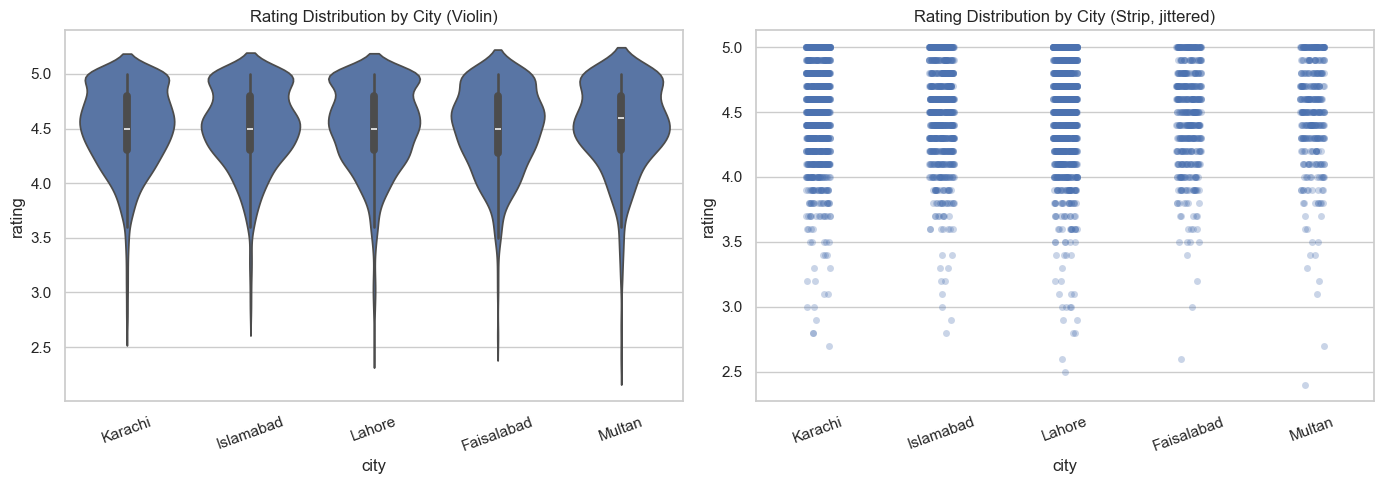

,mean,std,skew
city,,,
Faisalabad,4.490,0.384,-0.774
Islamabad,4.512,0.374,-0.805
Karachi,4.508,0.380,-0.906
Lahore,4.511,0.397,-1.014
Multan,4.521,0.401,-1.207


In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.violinplot(data=df, x='city', y='rating', ax=axes[0])
axes[0].set_title('Rating Distribution by City (Violin)')
axes[0].tick_params(axis='x', rotation=20)

sns.stripplot(data=df, x='city', y='rating', jitter=True, alpha=0.3, ax=axes[1])
axes[1].set_title('Rating Distribution by City (Strip, jittered)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

df.groupby('city')['rating'].agg(['mean','std','skew']).round(3)

**Which city is most inconsistent?** All five cities have almost the same *mean* rating (~4.49–4.52), so a bar-of-means would suggest they're basically identical. The violin/strip plots tell a different story: **Multan** has the highest standard deviation (0.40) and the most negative skew (-1.21), with ratings pulled down by a longer tail of low scores (down to 2.4) rather than a uniformly low average. So Multan's "problem" is inconsistency — a long left tail of bad experiences — not a low typical rating.

## Task 3 — Multivariate encoding
Delivery time vs. rating, with city encoded via hue and order value encoded via size.

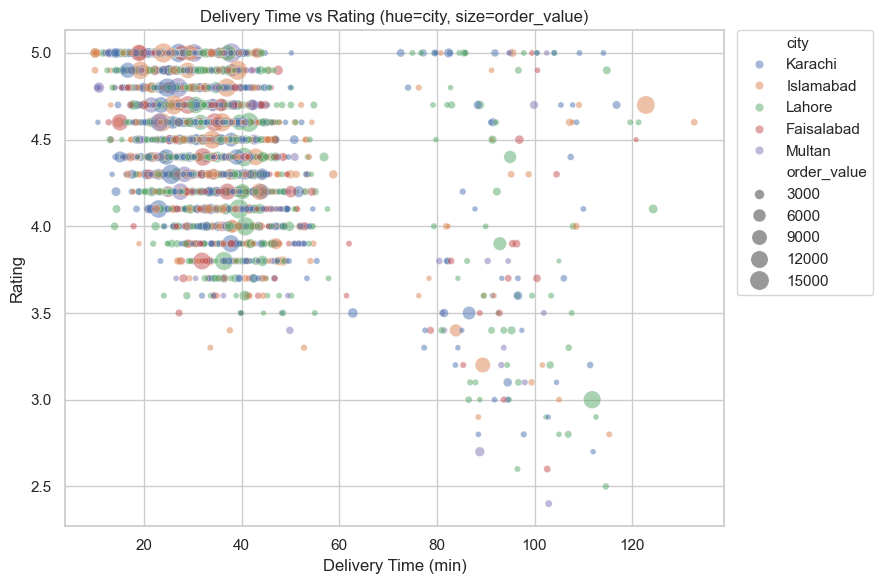

,delivery_time_min,rating
order_value_quartile,,
Q1 (low),34.59,4.50
Q2,35.29,4.51
Q3,34.39,4.50
Q4 (high),33.90,4.52


In [65]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x='delivery_time_min', y='rating', hue='city', size='order_value',
                 sizes=(15,200), alpha=0.5)
plt.title('Delivery Time vs Rating (hue=city, size=order_value)')
plt.xlabel('Delivery Time (min)')
plt.ylabel('Rating')
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

df['order_value_quartile'] = pd.qcut(df['order_value'], 4, labels=['Q1 (low)','Q2','Q3','Q4 (high)'])
df.groupby('order_value_quartile', observed=True)[['delivery_time_min','rating']].mean().round(2)

**Pattern:** The bubble sizes (order value) are scattered evenly across the whole plot — big bubbles show up at both fast and slow delivery times, and at both high and low ratings, just like small bubbles do. Splitting order value into quartiles confirms it: average delivery time and average rating barely move across quartiles (~34–35 min, ~4.50–4.52 across the board). So **high-value orders do not get faster or better-rated delivery** — order size is essentially independent of both delivery speed and rating, and that's only obvious once size is added as a fourth dimension; a plain 2D scatter would never have raised the question.

## Task 4 — Correlation: Pearson vs Spearman

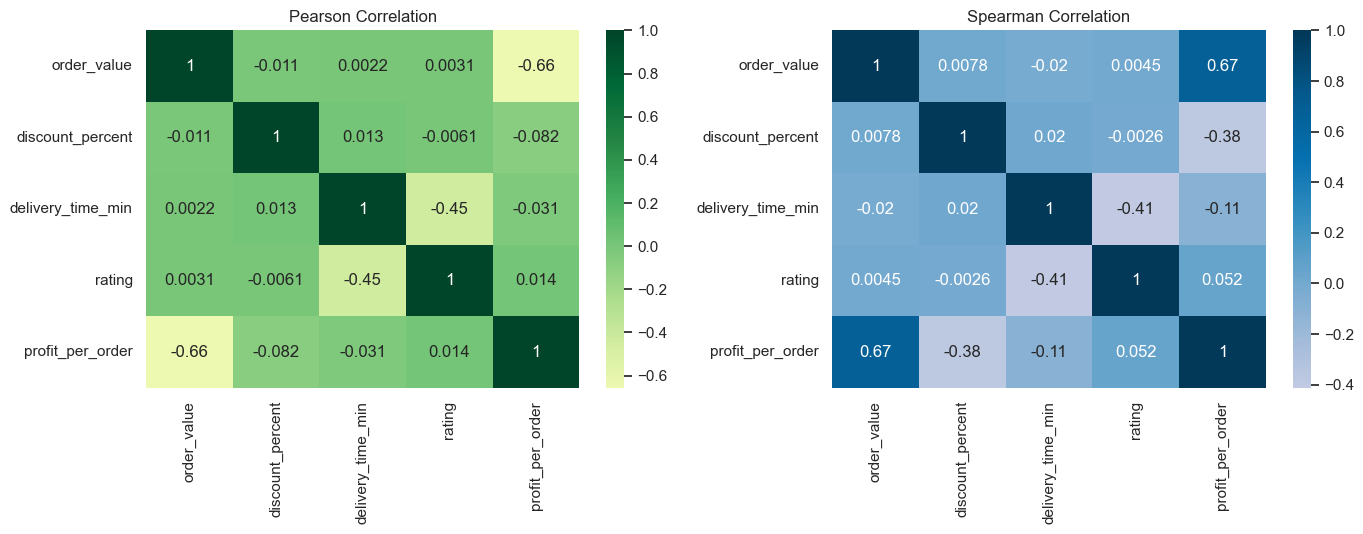

In [66]:
num_cols = ['order_value','discount_percent','delivery_time_min','rating','profit_per_order']
pearson_corr = df[num_cols].corr(method='pearson')
spearman_corr = df[num_cols].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(14,5.5))
sns.heatmap(pearson_corr, annot=True, cmap='YlGn', center=0, ax=axes[0])
axes[0].set_title('Pearson Correlation')
sns.heatmap(spearman_corr, annot=True, cmap='PuBu', center=0, ax=axes[1])
axes[1].set_title('Spearman Correlation')
plt.tight_layout()
plt.show()

In [67]:
diff = (pearson_corr - spearman_corr).abs()
mask = np.triu(np.ones(diff.shape), k=0).astype(bool)
diff_masked = diff.mask(mask)
top_pair = diff_masked.stack().idxmax()
top_diff = diff_masked.stack().max()
print(f"Largest disagreement: {top_pair} -> |Pearson - Spearman| = {top_diff:.3f}")
print(f"Pearson:  {pearson_corr.loc[top_pair]:.3f}")
print(f"Spearman: {spearman_corr.loc[top_pair]:.3f}")

Largest disagreement: ('profit_per_order', 'order_value') -> |Pearson - Spearman| = 1.330
Pearson:  -0.657
Spearman: 0.673


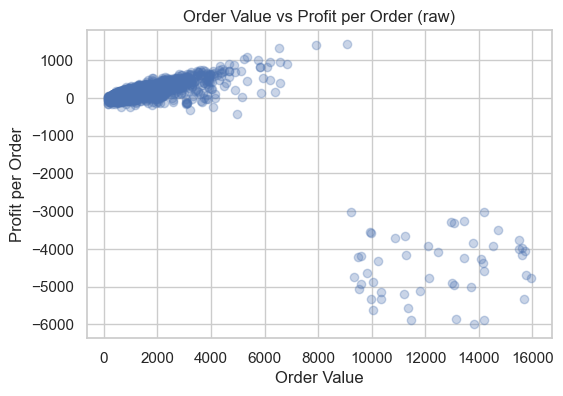

Orders with order_value > 5000: 70 out of 4200
        order_value  profit_per_order
count     70.000000         70.000000
mean   10662.246582      -2972.524566
std     3422.583202       2486.548111
min     5108.000000      -5994.457891
25%     7103.250000      -4856.846645
50%    10609.171903      -3979.569848
75%    13659.084688        155.750000
max    15943.033840       1423.000000


In [68]:
plt.figure(figsize=(6,4))
plt.scatter(df['order_value'], df['profit_per_order'], alpha=0.3)
plt.xlabel('Order Value')
plt.ylabel('Profit per Order')
plt.title('Order Value vs Profit per Order (raw)')
plt.show()

extreme = df[(df['order_value'] > 5000)]
print(f"Orders with order_value > 5000: {len(extreme)} out of {len(df)}")
print(extreme[['order_value','profit_per_order']].describe())

**Diagnosis:** `order_value` vs `profit_per_order` disagree the most — Pearson is **-0.66** (strong negative) while Spearman is **+0.67** (strong positive); the sign even flips. The scatter plot shows why: there's a small cluster of about 70 orders (under 2% of the data) with very large order values that also carry huge losses (profit down to -$5,994). Because Pearson works on raw values, these extreme points have outsized leverage and drag the whole relationship negative. Spearman only cares about ranks, so it isn't fooled by their magnitude and instead reflects what's true for the bulk of normal-sized orders: bigger orders tend to be more profitable.

This is a **handful of extreme orders**, not a genuine non-linear trend across the whole dataset — so yes, they should be flagged and set aside (or at least reported separately) before quoting a single correlation number to management, since the Pearson value on its own would mislead them into thinking bigger orders lose money.

**Correlation is not causation:** even after excluding the extreme orders, any correlation reported here only shows that two variables move together — it doesn't establish that one causes the other. The relationship could run either way, or be driven by a third factor (e.g. cuisine type or restaurant category) that affects both order value and profit.

## Task 5 — Layered aggregation
City × restaurant_category, average profit per order.

In [69]:
pivot_profit = pd.pivot_table(df, index='city', columns='restaurant_category',
                                values='profit_per_order', aggfunc='mean', margins=True)
pivot_profit.round(1)

restaurant_category,Cafe,Cloud Kitchen,Dessert,Fast Food,Fine Dining,All
city,,,,,,
Faisalabad,67.3,65.8,-70.3,20.2,293.7,51.9
Islamabad,-13.5,57.0,-27.9,37.2,153.1,35.5
Karachi,-38.9,136.7,75.2,15.4,302.8,74.1
Lahore,52.3,137.6,65.5,10.6,159.8,71.6
Multan,60.1,-82.8,55.9,-40.8,285.2,12.6
All,14.6,91.8,31.3,13.6,228.9,57.4


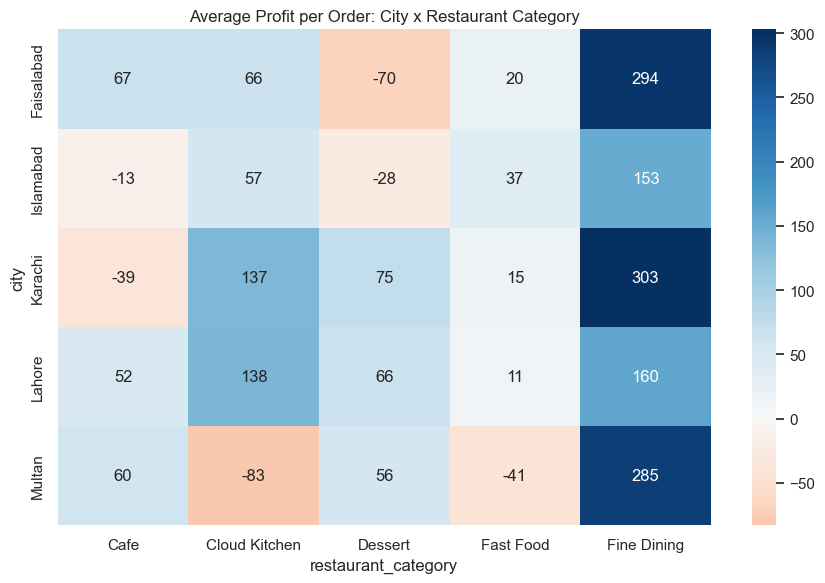

In [70]:
plt.figure(figsize=(9,6))
sns.heatmap(pivot_profit.drop('All', axis=0).drop('All', axis=1),
            annot=True, fmt='.0f', cmap='RdBu', center=0)
plt.title('Average Profit per Order: City x Restaurant Category')
plt.tight_layout()
plt.show()

In [71]:
profit_no_margins = pivot_profit.drop('All', axis=0).drop('All', axis=1)
best_profit_combo = profit_no_margins.stack().idxmax()
print(f"Most profitable combo (avg profit/order): {best_profit_combo} -> {profit_no_margins.stack().max():.1f}")

pivot_revenue = pd.pivot_table(df, index='city', columns='restaurant_category',
                                 values='order_value', aggfunc='sum')
best_revenue_combo = pivot_revenue.stack().idxmax()
print(f"Top revenue combo (total order value): {best_revenue_combo} -> {pivot_revenue.stack().max():,.0f}")

Most profitable combo (avg profit/order): ('Karachi', 'Fine Dining') -> 302.8
Top revenue combo (total order value): ('Lahore', 'Cloud Kitchen') -> 449,767


**Most profitable combination:** Karachi × Fine Dining, at roughly **$303 average profit per order**. That is *not* the same as the top revenue generator — **Lahore × Cloud Kitchen** brings in the most total revenue, but its average profit per order is much lower. High revenue and high per-order profitability point to different combinations here, which matters for management: Cloud Kitchen in Lahore is a volume play, while Fine Dining in Karachi is where each order is individually worth the most.

## Task 6 — Time-series: trend vs. noise
Monthly average rating, resampled first, then smoothed with a 3-month rolling average.

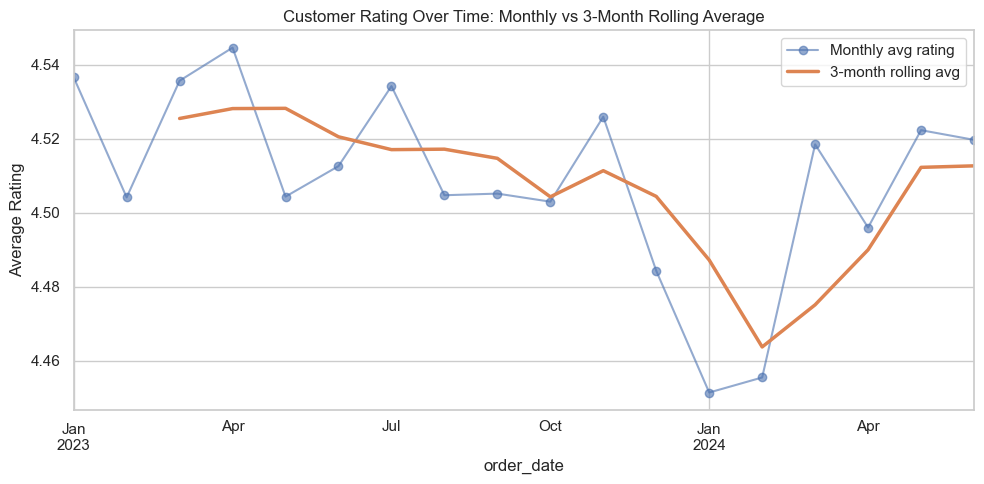

Rolling avg — first value: 4.526, last value: 4.513
Raw monthly — min: 4.451, max: 4.545


In [78]:
ts = df.set_index('order_date')
monthly_rating = ts['rating'].resample('ME').mean()
rolling_rating = monthly_rating.rolling(window=3).mean()

plt.figure(figsize=(10,5))
monthly_rating.plot(label='Monthly avg rating', marker='o', alpha=0.6)
rolling_rating.plot(label='3-month rolling avg', linewidth=2.5)
plt.legend()
plt.ylabel('Average Rating')
plt.title('Customer Rating Over Time: Monthly vs 3-Month Rolling Average')
plt.tight_layout()
plt.show()

print(f"Rolling avg — first value: {rolling_rating.dropna().iloc[0]:.3f}, last value: {rolling_rating.dropna().iloc[-1]:.3f}")
print(f"Raw monthly — min: {monthly_rating.min():.3f}, max: {monthly_rating.max():.3f}")

**Trend:** Once the 3-month rolling average smooths out the noise, customer satisfaction is essentially **flat with a mild dip** — it eases from about 4.53 down to roughly 4.46–4.48 around late 2023/early 2024, then recovers back to about 4.51 by mid-2024. The raw monthly line alone bounces around more sharply from month to month, and taken on its own could make a single bad or good month look like the start of a real trend when it's really just noise — which is exactly why the manual's rule (resample, then roll, never the other way) matters here.

## Task 7 — Faceting
`delivery_time_min` vs `rating`, faceted by restaurant_category, colored by whether the order was heavily discounted (>20%).

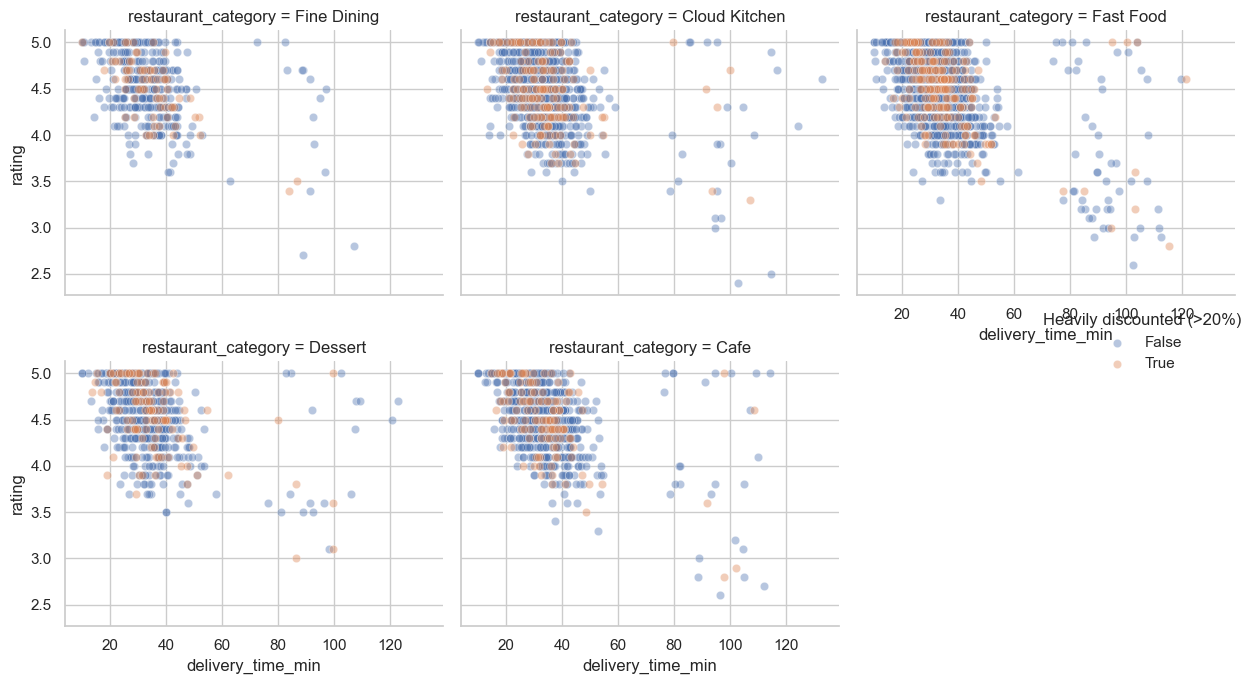

In [79]:
df['heavy_discount'] = df['discount_percent'] > 20

g = sns.FacetGrid(df, col='restaurant_category', hue='heavy_discount', col_wrap=3, height=3.5)
g.map(sns.scatterplot, 'delivery_time_min', 'rating', alpha=0.4)
g.add_legend(title='Heavily discounted (>20%)')
plt.tight_layout()
plt.show()

In [74]:
for cat in df['restaurant_category'].unique():
    sub = df[df['restaurant_category'] == cat]
    corr_normal = sub.loc[~sub['heavy_discount'], ['delivery_time_min','rating']].corr().iloc[0,1]
    corr_heavy = sub.loc[sub['heavy_discount'], ['delivery_time_min','rating']].corr().iloc[0,1]
    print(f"{cat:15s} normal-price corr: {corr_normal:.3f}   heavy-discount corr: {corr_heavy:.3f}")

Fine Dining     normal-price corr: -0.402   heavy-discount corr: -0.737
Cloud Kitchen   normal-price corr: -0.400   heavy-discount corr: -0.329
Fast Food       normal-price corr: -0.503   heavy-discount corr: -0.469
Dessert         normal-price corr: -0.340   heavy-discount corr: -0.516
Cafe            normal-price corr: -0.460   heavy-discount corr: -0.519


**Finding:** **Fine Dining** is the category where heavy discounting most visibly changes how forgiving customers are of slow delivery. The delivery-time-vs-rating relationship is already negative at full price (-0.40), but under a heavy discount it gets much steeper (-0.74) — discounted fine-dining customers punish slow delivery noticeably harder than full-price customers do, rather than being more forgiving because they got a deal.

## Task 8 — Overplotting + annotation
Raw order-level `delivery_time_min` vs `rating` — with 4,200 points and a limited set of repeated rating values, this is expected to overplot heavily.

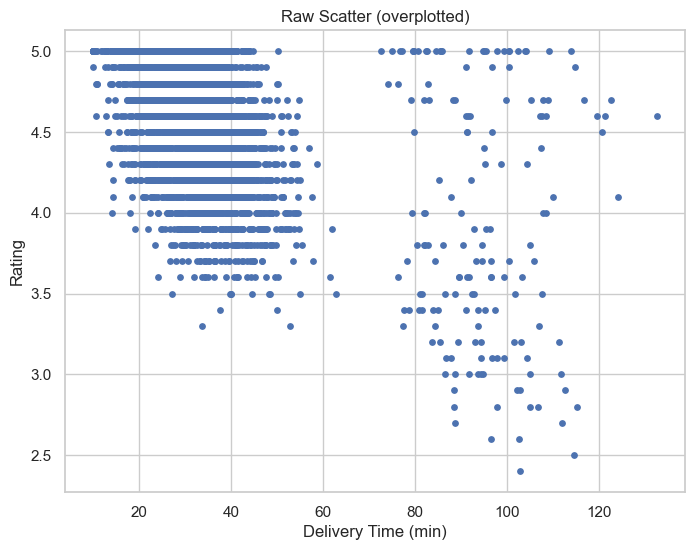

In [75]:
plt.figure(figsize=(8,6))
plt.scatter(df['delivery_time_min'], df['rating'], alpha=1.0, s=15)
plt.xlabel('Delivery Time (min)')
plt.ylabel('Rating')
plt.title('Raw Scatter (overplotted)')
plt.show()

The raw scatter is a solid smear along the repeated rating values — individual points can't be told apart. With 4,200 points and rating values clustering on a small set of discrete-looking levels, **transparency (alpha)** is the right fix here rather than hexbin: the dataset isn't large enough (50k+) to need binning, and alpha keeps individual extreme points (which we want to annotate) visible instead of folding them into a density grid.

In [76]:
long_thresh = df['delivery_time_min'].quantile(0.90)
short_thresh = df['delivery_time_min'].quantile(0.10)

long_deliveries = df[df['delivery_time_min'] >= long_thresh]
best_despite_long = long_deliveries.loc[long_deliveries['rating'].idxmax()]

short_deliveries = df[df['delivery_time_min'] <= short_thresh]
worst_despite_short = short_deliveries.loc[short_deliveries['rating'].idxmin()]

print("Best rating despite unusually long delivery:")
print(best_despite_long[['delivery_time_min','rating','city','restaurant_category']])
print()
print("Worst rating despite unusually fast delivery:")
print(worst_despite_short[['delivery_time_min','rating','city','restaurant_category']])

Best rating despite unusually long delivery:
delivery_time_min        79.5
rating                    5.0
city                   Lahore
restaurant_category      Cafe
Name: 143, dtype: object

Worst rating despite unusually fast delivery:
delivery_time_min           21.9
rating                       3.9
city                      Lahore
restaurant_category    Fast Food
Name: 286, dtype: object


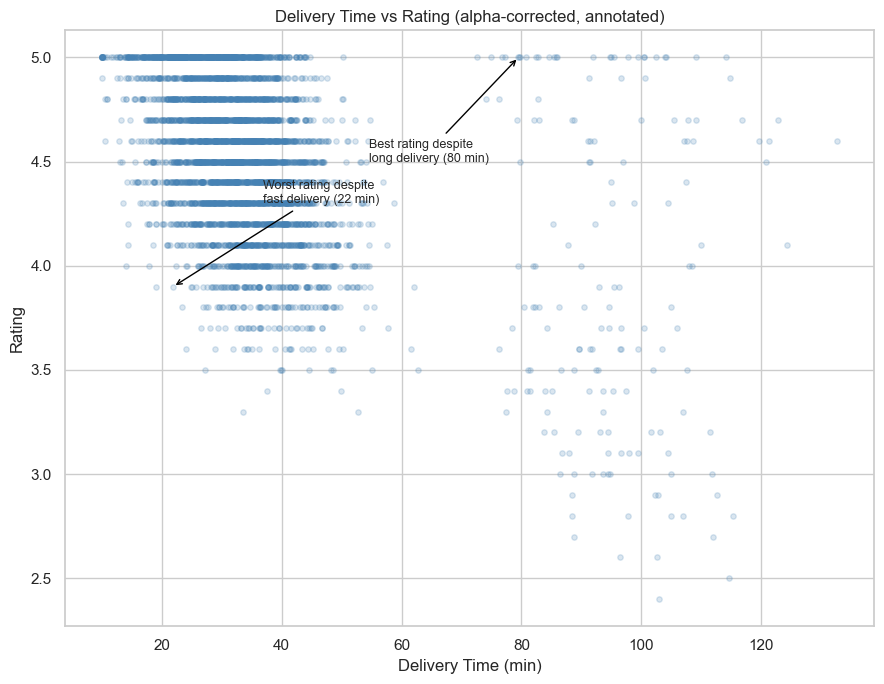

In [81]:
plt.figure(figsize=(9,7))
plt.scatter(df['delivery_time_min'], df['rating'], alpha=0.2, s=15, color='steelblue')

plt.annotate(f"Best rating despite\nlong delivery ({best_despite_long['delivery_time_min']:.0f} min)",
             xy=(best_despite_long['delivery_time_min'], best_despite_long['rating']),
             xytext=(best_despite_long['delivery_time_min']-25, best_despite_long['rating']-0.5),
             arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

plt.annotate(f"Worst rating despite\nfast delivery ({worst_despite_short['delivery_time_min']:.0f} min)",
             xy=(worst_despite_short['delivery_time_min'], worst_despite_short['rating']),
             xytext=(worst_despite_short['delivery_time_min']+15, worst_despite_short['rating']+0.4),
             arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

plt.xlabel('Delivery Time (min)')
plt.ylabel('Rating')
plt.title('Delivery Time vs Rating (alpha-corrected, annotated)')
plt.tight_layout()
plt.show()